# 01 Data Exploration

This notebook loads the selected inflammatory bowel disease single-cell RNA-seq dataset and inspects its expression matrix, metadata, and biological labels.

Initial focus: immune cells from ulcerative colitis and healthy colon tissue.

## 1. Setup

Import Python packages and configure plotting settings.

In [32]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.io import mmread

sc.settings.verbosity = 3
sc.set_figure_params(dpi=100, facecolor="white")

## 2. Define File Paths

Define paths to the raw immune-cell expression matrix, barcode file, gene file, metadata file, and t-SNE coordinates.

In [33]:
DATA_DIR = Path("../data/raw")

matrix_path = DATA_DIR / "gene_sorted-Imm.matrix.mtx"
barcodes_path = DATA_DIR / "Imm.barcodes2.tsv"
genes_path = DATA_DIR / "Imm.genes.tsv"
metadata_path = DATA_DIR / "all.meta2.txt"
tsne_path = DATA_DIR / "Imm.tsne.txt"

for path in [matrix_path, barcodes_path, genes_path, metadata_path, tsne_path]:
    print(path, path.exists())

..\data\raw\gene_sorted-Imm.matrix.mtx True
..\data\raw\Imm.barcodes2.tsv True
..\data\raw\Imm.genes.tsv True
..\data\raw\all.meta2.txt True
..\data\raw\Imm.tsne.txt True


## 3. Load Immune Expression Data

Load the Matrix Market expression matrix, immune cell barcodes, and gene names.

In [34]:
matrix = mmread(matrix_path).tocsr()
barcodes = pd.read_csv(barcodes_path, sep="\t", header=None)
genes = pd.read_csv(genes_path, sep="\t", header=None)

matrix.shape, barcodes.shape, genes.shape

C:\Users\Shane Thomas\AppData\Local\Temp\ipykernel_7800\2640531597.py:1: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  matrix = mmread(matrix_path).tocsr()


((20529, 210614), (210614, 1), (20529, 1))

## 4. Create AnnData Object

Create a Scanpy AnnData object. The matrix is transposed because the raw file is stored as genes x cells, while Scanpy expects cells x genes.

In [35]:
adata = sc.AnnData(X=matrix.T)

adata.obs_names = barcodes[0].astype(str).values
adata.var_names = genes[0].astype(str).values
adata.var_names_make_unique()

adata

AnnData object with n_obs × n_vars = 210614 × 20529

## 5. Load And Clean Metadata

Load cell-level metadata and remove the non-cell type-description row.

In [36]:
metadata = pd.read_csv(metadata_path, sep="\t")

metadata = metadata[metadata["NAME"] != "TYPE"].copy()
metadata["nGene"] = pd.to_numeric(metadata["nGene"])
metadata["nUMI"] = pd.to_numeric(metadata["nUMI"])

metadata.head()

C:\Users\Shane Thomas\AppData\Local\Temp\ipykernel_7800\2555447411.py:1: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(metadata_path, sep="\t")


,NAME,Cluster,nGene,nUMI,Subject,Health,Location,Sample
1,N7.EpiA.AAACATACACACTG,TA 1,328,891,N7,Non-inflamed,Epi,N7.EpiA
2,N7.EpiA.AAACCGTGCATCAG,TA 1,257,663,N7,Non-inflamed,Epi,N7.EpiA
3,N7.EpiA.AAACGCACAATCGC,TA 2,300,639,N7,Non-inflamed,Epi,N7.EpiA
4,N7.EpiA.AAAGATCTAACCGT,Enterocyte Progenitors,250,649,N7,Non-inflamed,Epi,N7.EpiA
5,N7.EpiA.AAAGATCTAGGCGA,Enterocyte Progenitors,284,769,N7,Non-inflamed,Epi,N7.EpiA


## 6. Attach Metadata To AnnData

Match metadata rows to immune cell barcodes and attach the metadata to `adata.obs`.

In [38]:
metadata_indexed = metadata.set_index("NAME")

common_cells = adata.obs_names.intersection(metadata_indexed.index)

print("Cells in immune expression matrix:", adata.n_obs)
print("Cells with matching metadata:", len(common_cells))

adata = adata[common_cells].copy()
adata.obs = metadata_indexed.loc[common_cells].copy()

adata

Cells in immune expression matrix: 210614
Cells with matching metadata: 210614


AnnData object with n_obs × n_vars = 210614 × 20529
    obs: 'Cluster', 'nGene', 'nUMI', 'Subject', 'Health', 'Location', 'Sample'

## 7. Dataset Summary

Inspect tissue condition labels, subject-level cell counts, and immune cluster annotations.

In [46]:
adata.obs["Health"].value_counts()

Health
Inflamed        91830
Non-inflamed    67412
Healthy         51372
Name: count, dtype: int64

In [47]:
adata.obs["Subject"].value_counts().head(10)

Subject
N661    39058
N111    20425
N52     19002
N58     15389
N51     11266
N44     10790
N10      7824
N50      7649
N23      6474
N49      6345
Name: count, dtype: int64

In [48]:
adata.obs["Cluster"].value_counts().head(20)

Cluster
Plasma                    82651
CD4+ Memory               26809
Follicular                21468
Macrophages               16692
CD8+ LP                   14935
CD4+ Activated Fos-hi     10406
CD4+ Activated Fos-lo      9421
Tregs                      6473
CD69+ Mast                 5654
CD8+ IELs                  3576
DC2                        2391
Cycling B                  2211
NKs                        2023
Inflammatory Monocytes     1652
GC                          916
Cycling T                   557
ILCs                        509
CD8+ IL17+                  490
MT-hi                       442
DC1                         428
Name: count, dtype: int64

## 8. Immune Cell Composition By Condition

Compare immune cell cluster proportions across healthy, non-inflamed, and inflamed tissue.

In [49]:
cluster_health_counts = pd.crosstab(adata.obs["Cluster"], adata.obs["Health"])

cluster_health_props = cluster_health_counts.div(
    cluster_health_counts.sum(axis=0),
    axis=1
) * 100

cluster_health_props.head()

Health,Healthy,Inflamed,Non-inflamed
Cluster,,,
CD4+ Activated Fos-hi,6.859768,3.178700,5.878775
CD4+ Activated Fos-lo,6.927898,3.046935,4.545185
CD4+ Memory,9.719302,13.211369,14.365395
CD4+ PD1+,0.145994,0.320157,0.071204
CD69+ Mast,1.810325,2.821518,3.164125


## 9. Visualize Top Immune Cell Populations

Plot the relative abundance of the most common immune cell clusters across tissue conditions.

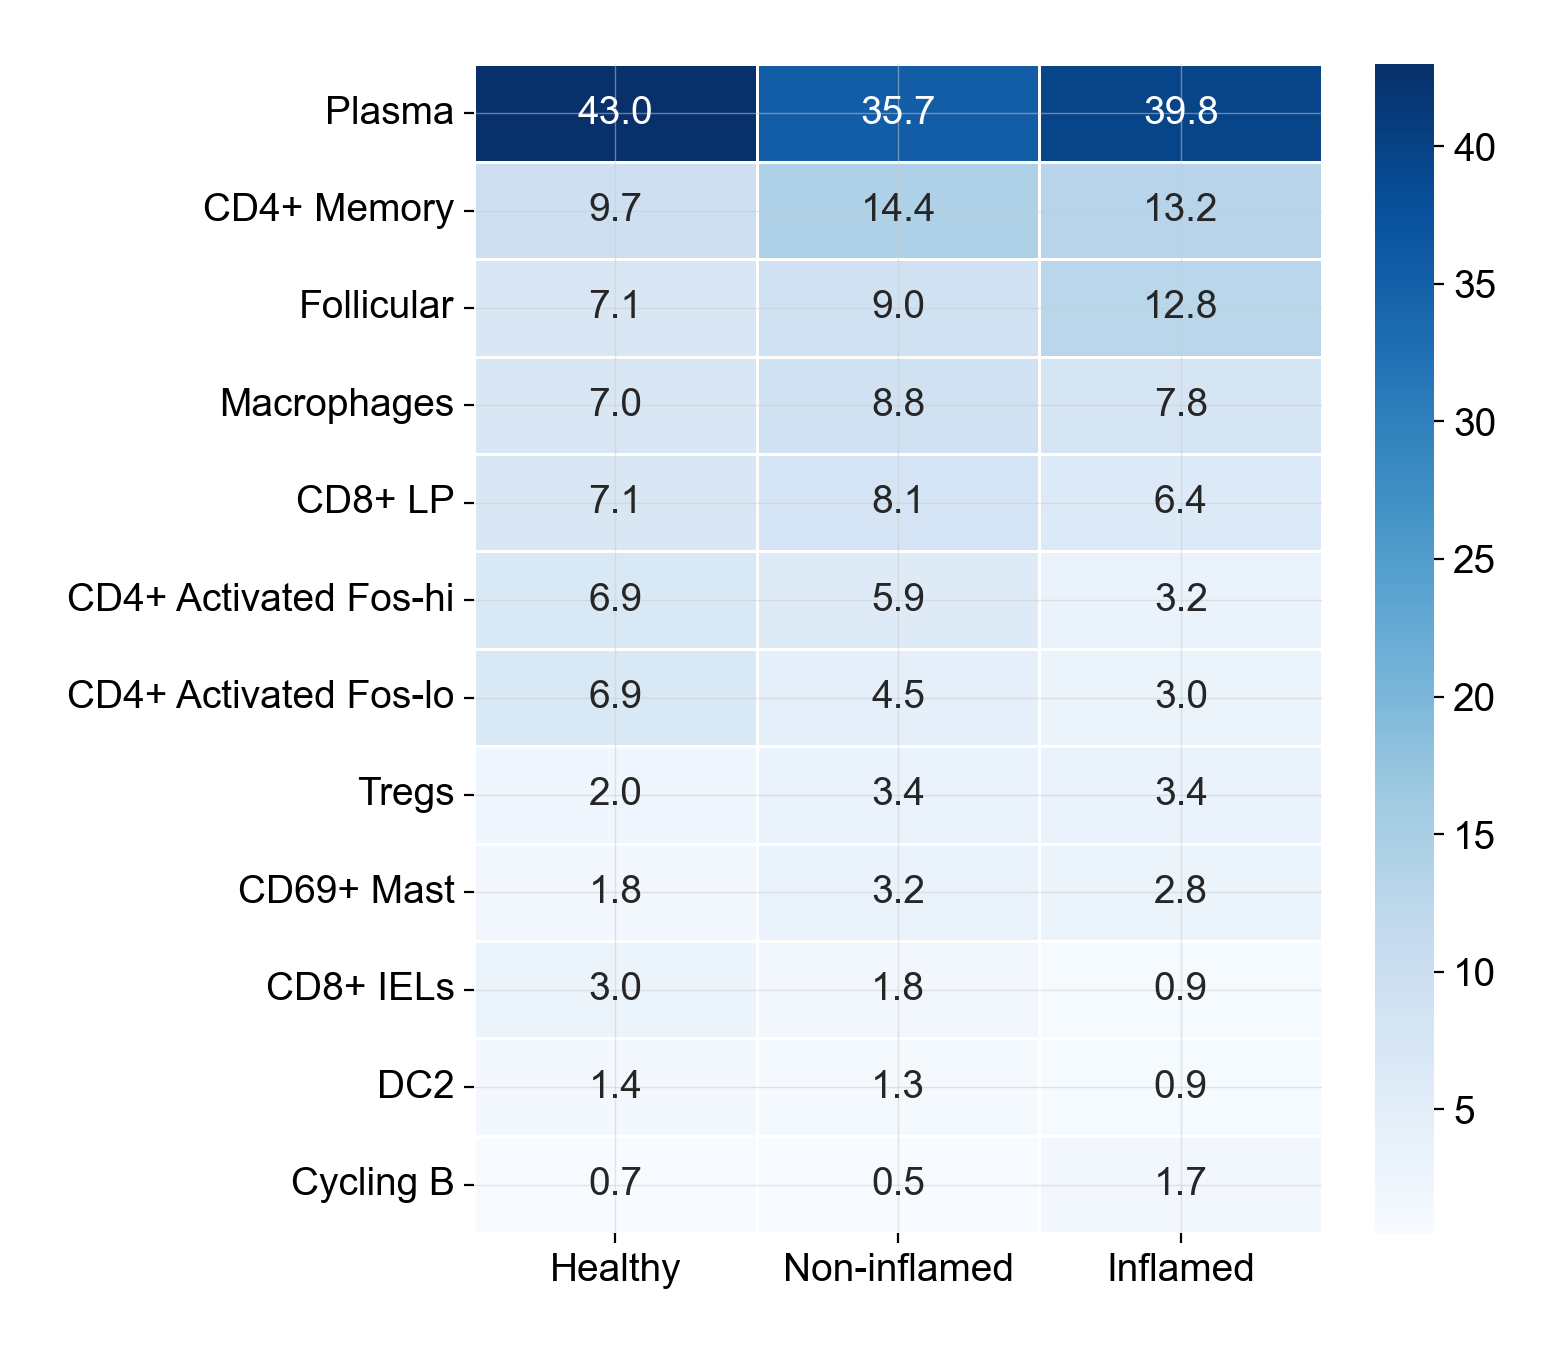

In [56]:
top_clusters = adata.obs["Cluster"].value_counts().head(12).index

heatmap_data = cluster_health_props.loc[
    top_clusters,
    ["Healthy", "Non-inflamed", "Inflamed"]
]

plt.figure(figsize=(8, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Percentage of immune cells"}
)

plt.xlabel("Tissue condition")
plt.ylabel("Immune cell cluster")
plt.title("Top immune cell populations by tissue condition")

plt.tight_layout()
plt.savefig("../results/figures/top_immune_clusters_by_condition_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Initial Composition Findings

The heatmap suggests that immune cell composition varies across healthy, non-inflamed, and inflamed intestinal tissue. Some populations, such as follicular cells and cycling B cells, appear proportionally higher in inflamed tissue, while activated CD4+ Fos-hi/Fos-lo populations and CD8+ IELs appear lower.

These exploratory composition differences provide candidate cell populations for downstream marker gene and disease-associated expression analysis.

## 11. Save Composition Summary Tables

The cell composition summaries are saved as CSV files so they can be inspected outside the notebook, reused in later analyses, and tracked as project results.

In [59]:
composition_table_path = "../results/tables/immune_cluster_composition_by_condition.csv"

cluster_health_props.to_csv(composition_table_path)

composition_table_path

'../results/tables/immune_cluster_composition_by_condition.csv'

## 12. Quantify Composition Changes

To identify immune populations with the largest condition-associated shifts, cluster proportions are compared between inflamed and healthy tissue. Positive values indicate higher relative abundance in inflamed tissue, while negative values indicate lower relative abundance.

In [60]:
composition_changes = cluster_health_props[
    ["Healthy", "Non-inflamed", "Inflamed"]
].copy()

composition_changes["Inflamed_minus_Healthy"] = (
    composition_changes["Inflamed"] - composition_changes["Healthy"]
)

composition_changes["Noninflamed_minus_Healthy"] = (
    composition_changes["Non-inflamed"] - composition_changes["Healthy"]
)

composition_changes["Abs_inflamed_change"] = (
    composition_changes["Inflamed_minus_Healthy"].abs()
)

composition_changes = composition_changes.sort_values(
    "Abs_inflamed_change",
    ascending=False
)

composition_changes.head(15)

Health,Healthy,Non-inflamed,Inflamed,Inflamed_minus_Healthy,Noninflamed_minus_Healthy,Abs_inflamed_change
Cluster,,,,,,
Follicular,7.050533,8.968730,12.849831,5.799298,1.918196,5.799298
CD4+ Activated Fos-lo,6.927898,4.545185,3.046935,-3.880964,-2.382714,3.880964
CD4+ Activated Fos-hi,6.859768,5.878775,3.178700,-3.681068,-0.980993,3.681068
CD4+ Memory,9.719302,14.365395,13.211369,3.492066,4.646093,3.492066
Plasma,42.976719,35.665757,39.780028,-3.196691,-7.310962,3.196691
CD8+ IELs,2.962703,1.774165,0.934335,-2.028368,-1.188539,2.028368
Tregs,2.040022,3.425206,3.393227,1.353205,1.385184,1.353205
Cycling B,0.650160,0.492494,1.682457,1.032297,-0.157666,1.032297
CD69+ Mast,1.810325,3.164125,2.821518,1.011193,1.353800,1.011193


## 13. Save Composition Change Table

The ranked composition change table is saved for downstream reporting and interpretation.

In [61]:
changes_table_path = "../results/tables/immune_cluster_composition_changes.csv"

composition_changes.to_csv(changes_table_path)

changes_table_path

'../results/tables/immune_cluster_composition_changes.csv'

## 14. Notebook Summary

This notebook loaded the immune-cell portion of a public inflammatory bowel disease single-cell RNA-seq dataset, attached cell-level metadata, and compared immune cell composition across healthy, non-inflamed, and inflamed intestinal tissue.

The initial exploratory analysis identified condition-associated differences in immune cell populations, providing candidate clusters for downstream marker gene and disease-associated expression analysis.